<div align="center" style="background-color:#292524; padding:30px; border-radius:12px; box-shadow:0 0 25px rgba(0,0,0,0.08);">

# 🎾 ATP Tennis Dataset (2000–2025)

<p style="font-size:18px; color:#D6D3D1; max-width:750px; margin:auto;">
An extensive dataset with over <strong style="color:#1e90ff;">60,000</strong> professional ATP matches played between <strong>2000</strong> and <strong>2025</strong>, designed for data analysts, machine learning engineers, and tennis enthusiasts.
</p>
</div>


---

### 📦 Dataset Highlights

- 🏟 **Tournament** name, type, and location  
- 📅 **Date** and **match round** (e.g., Quarterfinals, Finals)  
- 🌍 **Indoor/Outdoor** and **surface type** (Clay, Grass, Hard)  
- 🧍‍♂️ **Players** names, **ranking**, and **winner**  
- 🎯 **Odds** for each player  
- 🧾 **Score** and **match format** (Best of 3 or 5 sets)

---

### 🔍 Perfect For:
- 🎓 Sports analytics & performance modeling  
- 📊 Predictive modeling with ML (e.g., who wins based on rank & odds)  
- 🎯 Betting pattern analysis  
- 📈 Player trend exploration over the years  

---



### ❤️ Support the Project

If you found this dataset useful:

👉 **Leave an upvote**  
💬 **Share your feedback**  
📢 **Mention it in your projects**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/atp-tennis-2000-2023daily-pull/atp_tennis.csv


<div style="background: linear-gradient(to right, #0f2027, #203a43, #2c5364); border-radius: 15px; padding: 20px; text-align: center; color: #e0f7fa; box-shadow: 0 4px 12px rgba(0,0,0,0.4);">
  <h2 style="color: #ffd54f;">🎾Data Handling</h2>
  <p style="font-size: 16px;">
  </p>
</div>


In [2]:
#read data
df=pd.read_csv('/kaggle/input/atp-tennis-2000-2023daily-pull/atp_tennis.csv')

#show shape of data
print(f'Data shape : {df.shape}')
#show missing value
print(f'Missing value in data = {df.isnull().sum()}')
#show duplicated value 
print(f'Duplicated data : {df.duplicated().sum()}')


Data shape : (65884, 17)
Missing value in data = Tournament    0
Date          0
Series        0
Court         0
Surface       0
Round         0
Best of       0
Player_1      0
Player_2      0
Winner        0
Rank_1        0
Rank_2        0
Pts_1         0
Pts_2         0
Odd_1         0
Odd_2         0
Score         0
dtype: int64
Duplicated data : 0


In [3]:
#show sample of data
df.sample()

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
26976,US Open,2009-09-02,Grand Slam,Outdoor,Hard,1st Round,5,Ferrero J.C.,Santoro F.,Ferrero J.C.,25,44,1490,1072,1.2,4.33,6-4 6-3 6-3


In [4]:
#info about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65884 entries, 0 to 65883
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tournament  65884 non-null  object 
 1   Date        65884 non-null  object 
 2   Series      65884 non-null  object 
 3   Court       65884 non-null  object 
 4   Surface     65884 non-null  object 
 5   Round       65884 non-null  object 
 6   Best of     65884 non-null  int64  
 7   Player_1    65884 non-null  object 
 8   Player_2    65884 non-null  object 
 9   Winner      65884 non-null  object 
 10  Rank_1      65884 non-null  int64  
 11  Rank_2      65884 non-null  int64  
 12  Pts_1       65884 non-null  int64  
 13  Pts_2       65884 non-null  int64  
 14  Odd_1       65884 non-null  float64
 15  Odd_2       65884 non-null  float64
 16  Score       65884 non-null  object 
dtypes: float64(2), int64(5), object(10)
memory usage: 8.5+ MB


In [5]:
df.describe()

,Best of,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2
count,65884.000000,65884.000000,65884.000000,65884.000000,65884.000000,65884.000000,65884.000000
mean,3.378392,75.888835,75.614428,1126.829625,1131.573812,2.410349,2.409366
std,0.783335,100.607793,101.040522,1715.540143,1738.245472,2.653615,2.641955
min,3.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,3.000000,24.000000,25.000000,98.000000,99.000000,1.333000,1.333000
50%,3.000000,53.000000,54.000000,696.000000,696.000000,1.730000,1.800000
75%,3.000000,92.000000,92.000000,1240.000000,1245.000000,2.750000,2.750000
max,5.000000,3390.000000,4915.000000,16950.000000,16950.000000,67.000000,51.000000


## **Data representation**

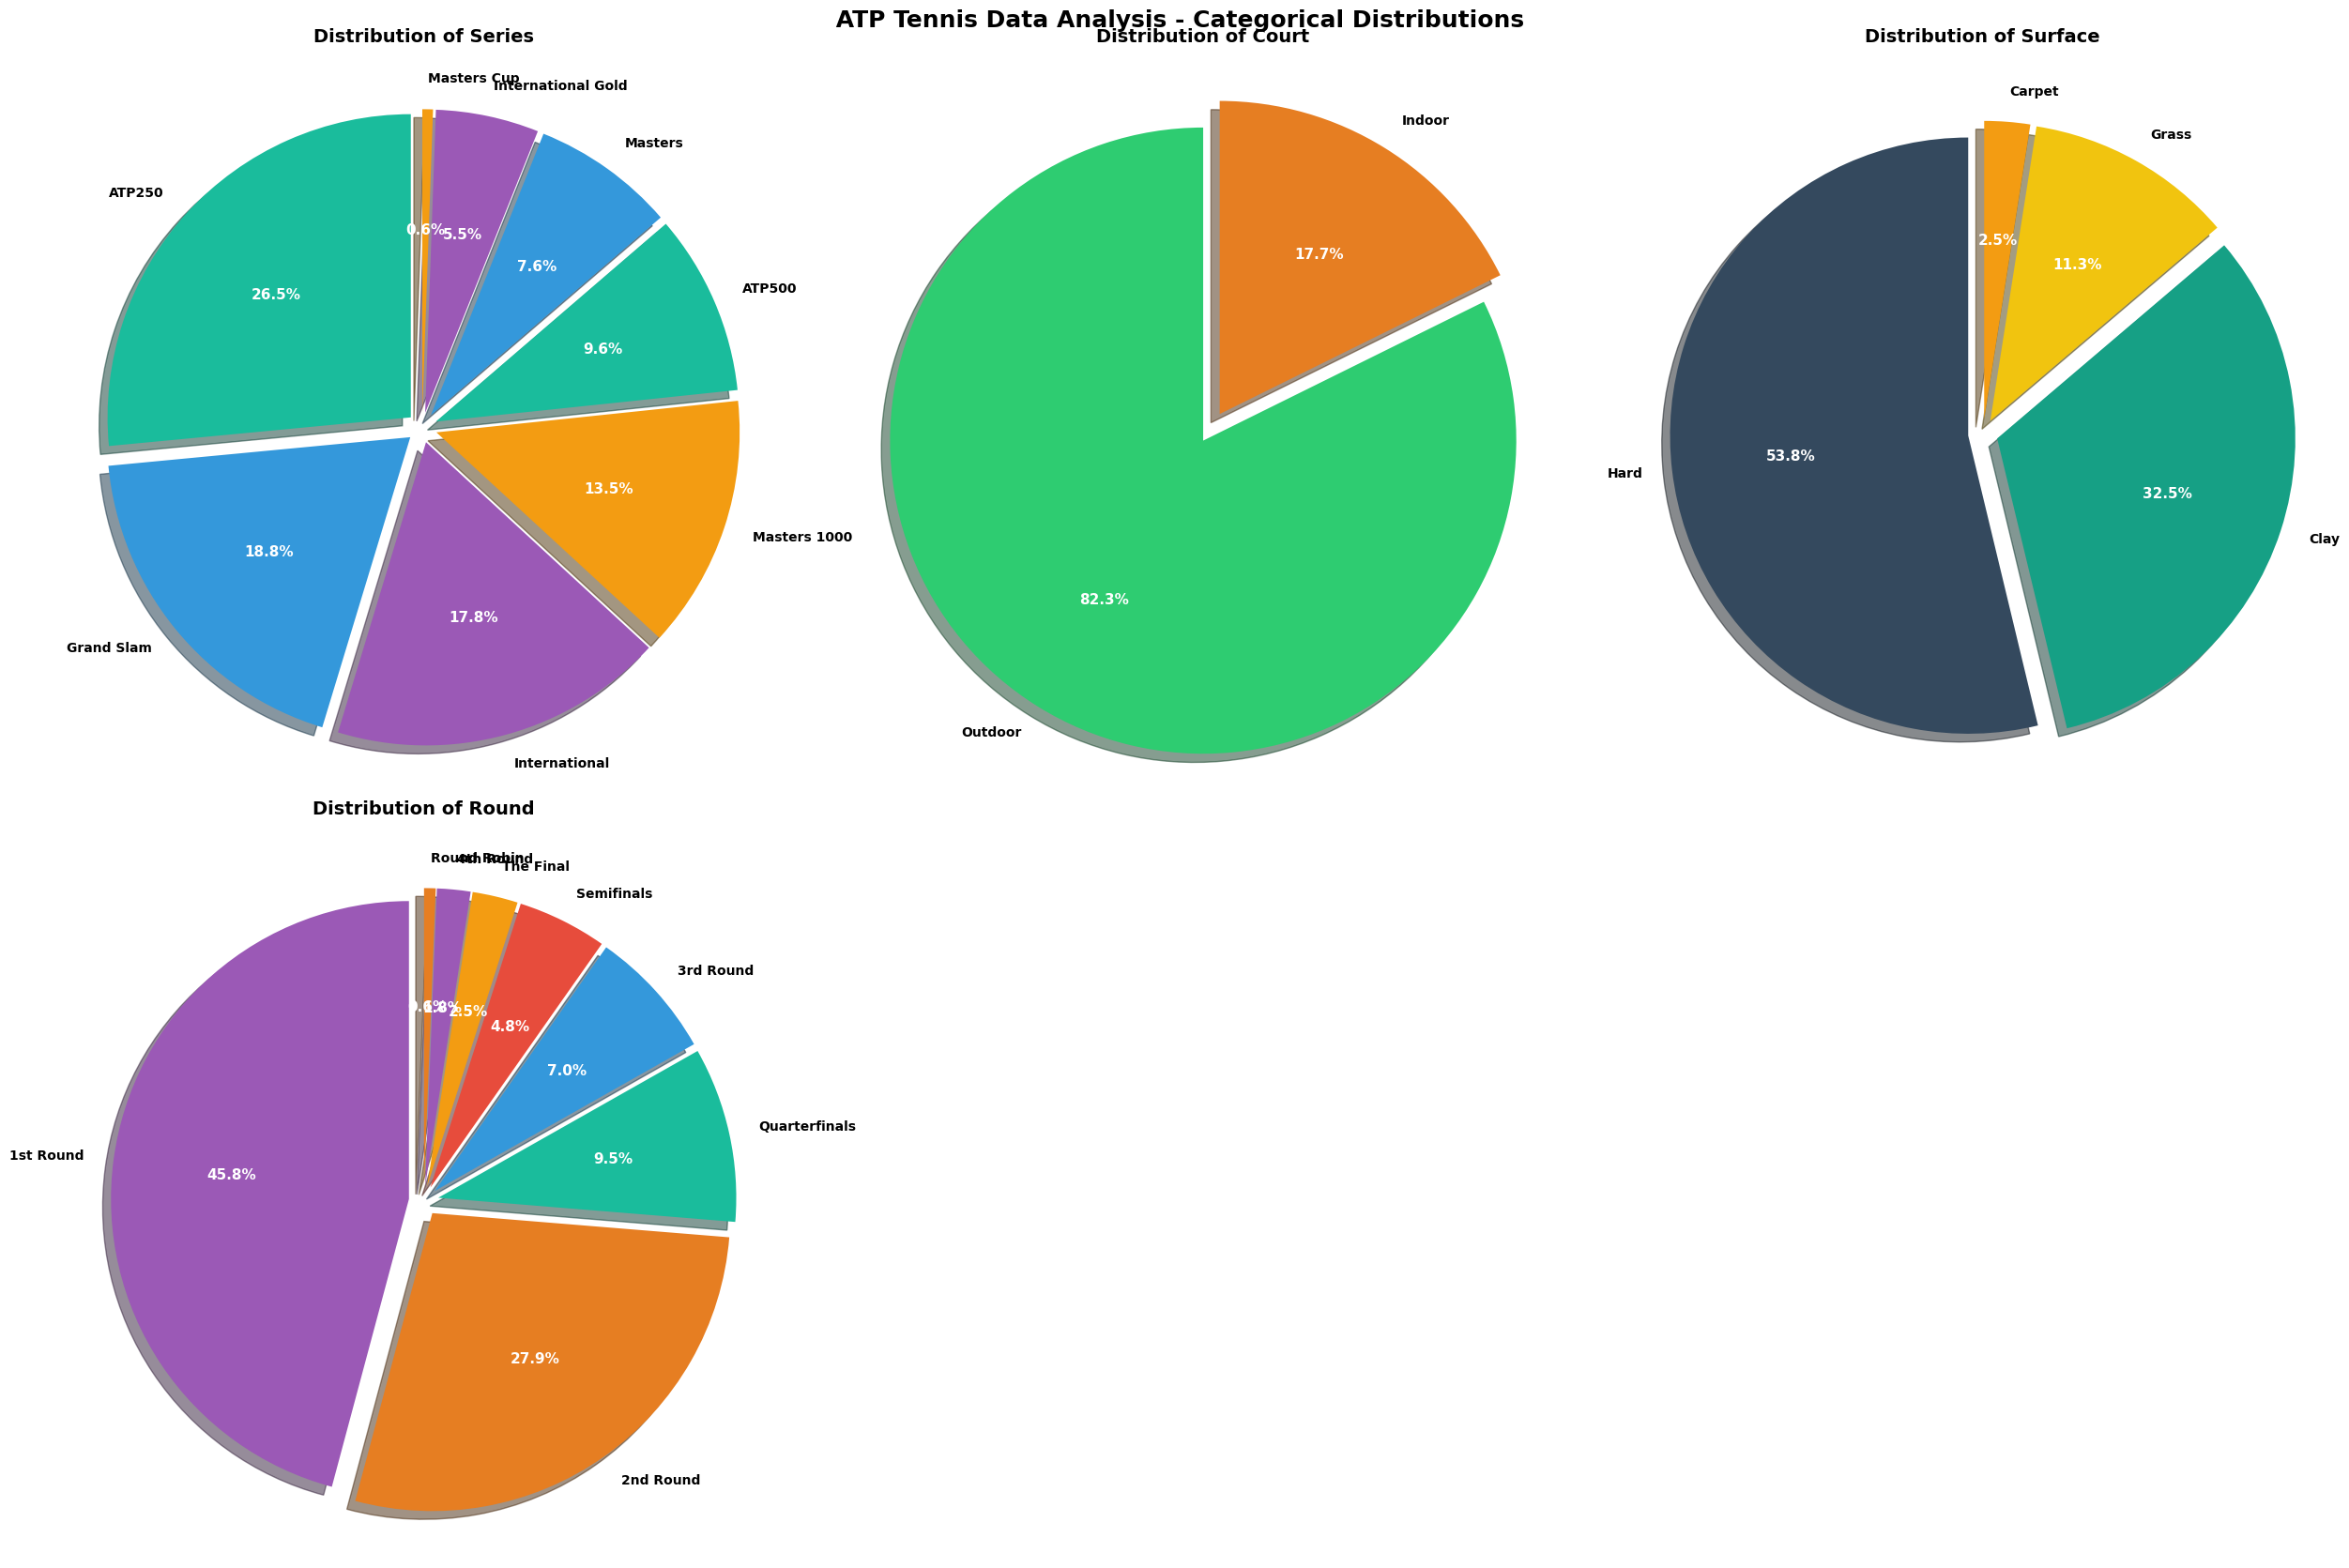

In [6]:
# Show all category percentages
category = ['Series', 'Court', 'Surface', 'Round']

# Color palettes
color_palettes = {
    'Series': ['#1abc9c', '#3498db', '#9b59b6', '#f39c12'],
    'Court': ['#2ecc71', '#e67e22', '#e74c3c'],
    'Surface': ['#34495e', '#16a085', '#f1c40f','#f39c12'],
    'Round': ['#9b59b6', '#e67e22', '#1abc9c', '#3498db', '#e74c3c', '#f39c12']
}

# Create figure
plt.figure(figsize=(25, 17))

# Loop through each column and plot pie chart
for i, col in enumerate(category, 1):
    plt.subplot(2, 3, i)
    value_counts = df[col].value_counts()
    
    # Choose color palette based on column
    colors = color_palettes[col][:len(value_counts)]
    
    # Draw pie chart
    wedges, texts, autotexts = plt.pie(
        value_counts.values,
        labels=value_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        explode=[0.05] * len(value_counts),
        shadow=True,
        textprops={'fontsize': 10, 'fontweight': 'bold'}
    )
    
    # Enhance percentage text inside slices
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(11)
    
    # Title for each pie chart
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold', pad=20)
    plt.axis('equal')

# Overall title
plt.suptitle(' ATP Tennis Data Analysis - Categorical Distributions', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


###  Categorical Features Distribution

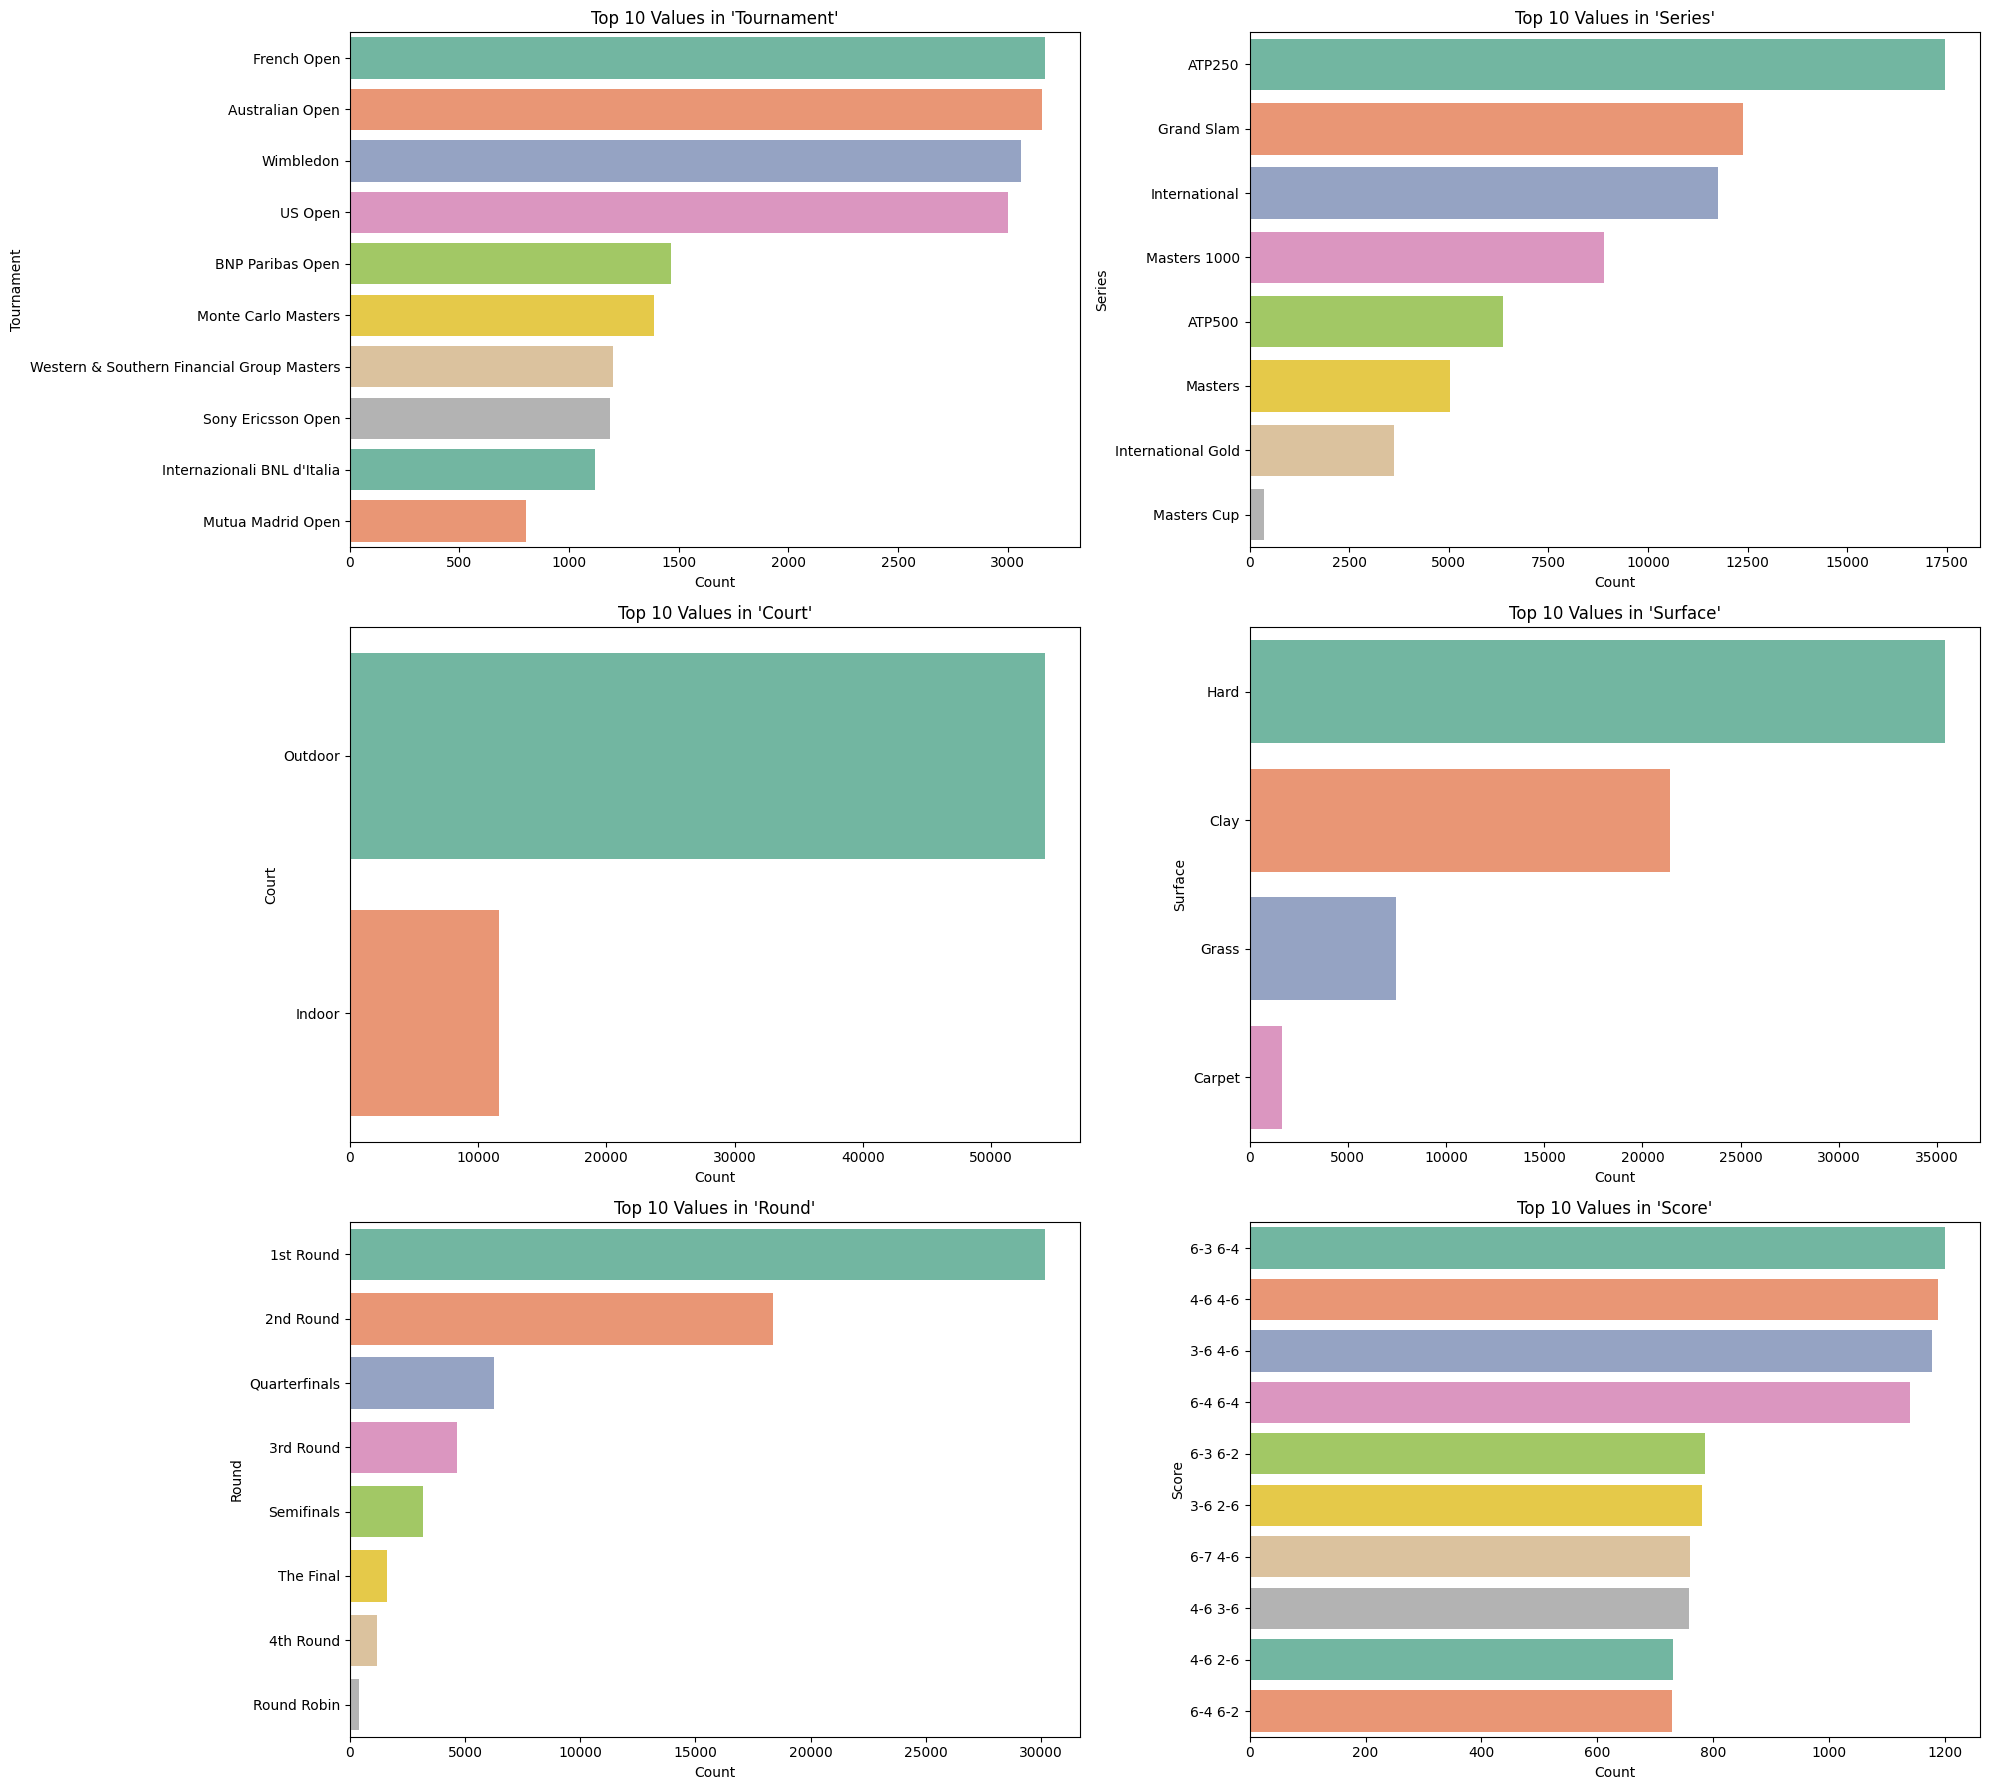

In [7]:
categorical_cols = ['Tournament', 'Series', 'Court', 'Surface', 'Round', 'Score']
plt.figure(figsize=(20, 18))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 2, i)
    top_values = df[col].value_counts().nlargest(10)
    sns.barplot(y=top_values.index, x=top_values.values, palette='Set2')
    plt.title(f"Top 10 Values in '{col}'", fontsize=12)
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()


### 📈 2. Numerical Features Distribution


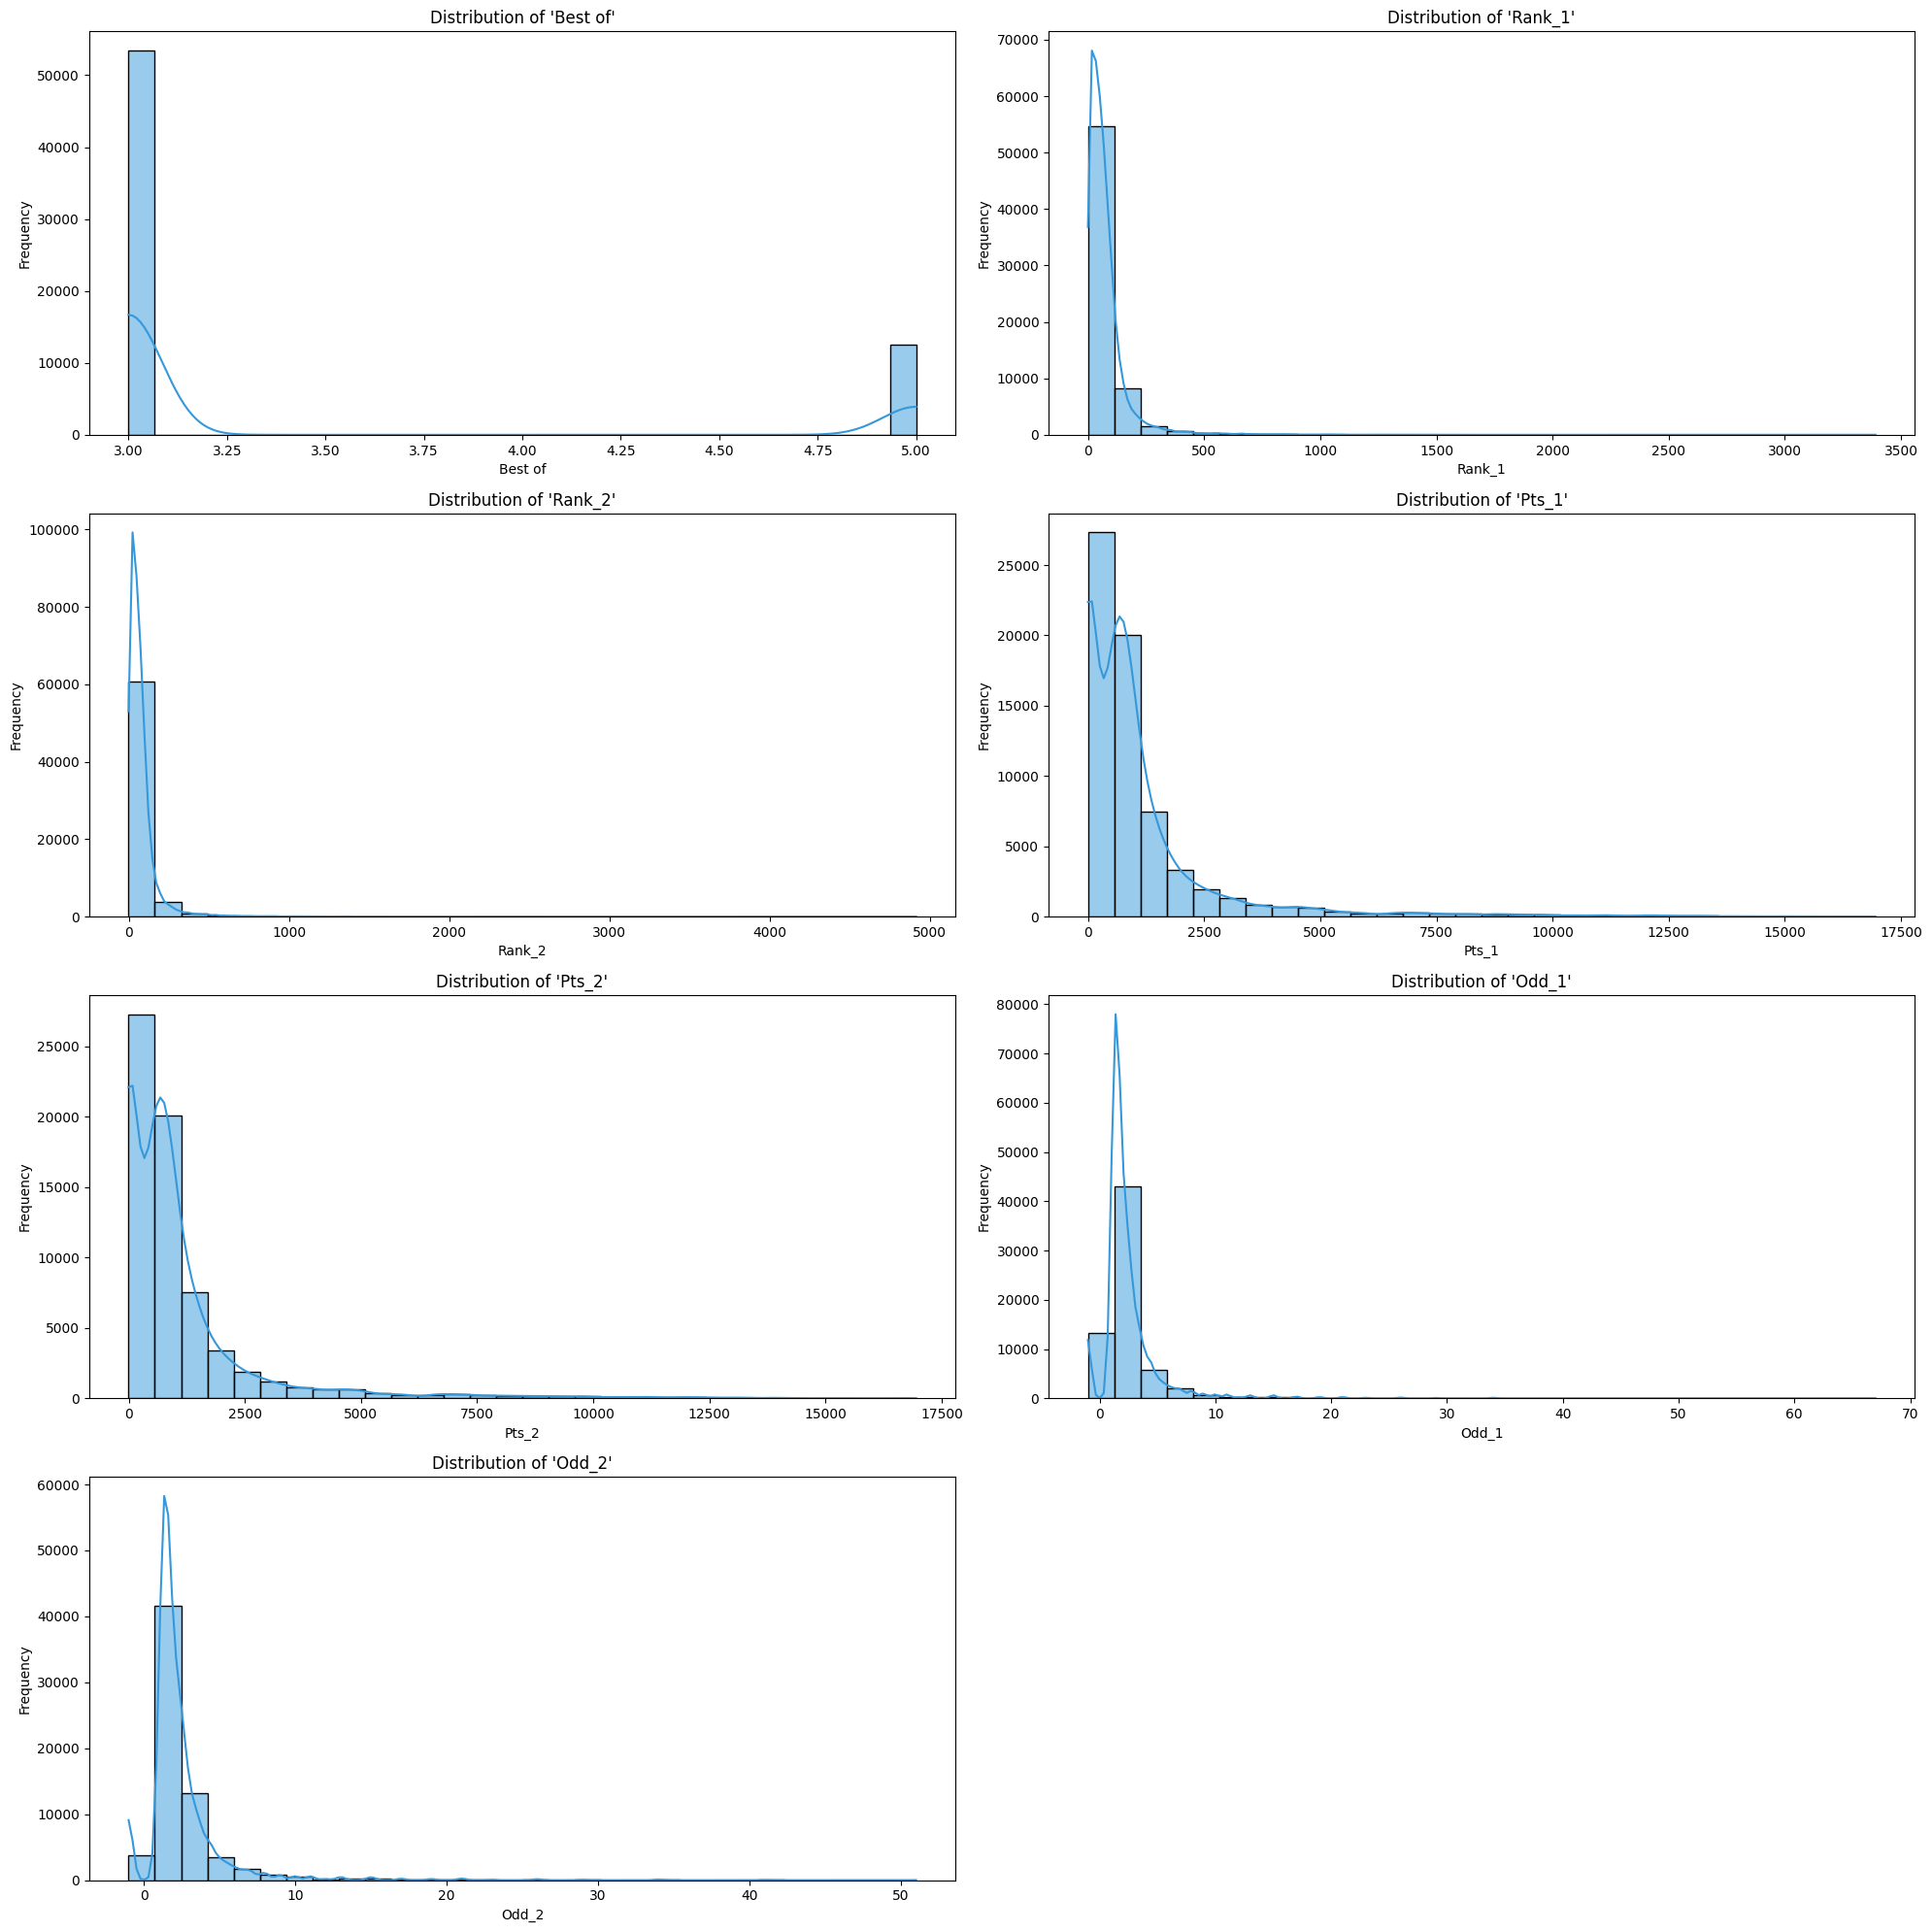

In [8]:
#show distrbution in best of , Rank_1 , Rank_2 ,pts ,odd
numerical_cols = ['Best of', 'Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2']
plt.figure(figsize=(20, 20))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[col], kde=True, bins=30, color='#3498db')
    plt.title(f"Distribution of '{col}'", fontsize=12)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()


## **🛠️ Next Steps - Advanced Analysis**

### Player Development Analysis

In [9]:
# Top 10 most frequent tournaments
tournament_counts = df['Tournament'].value_counts().head(10)
#Tournament Surfaces
surface_distribution = df.groupby(['Tournament', 'Surface']).size().unstack()
#Matches Over Time
df['Year'] = pd.to_datetime(df['Date']).dt.year
matches_per_year = df['Year'].value_counts().sort_index()
# Create a dataframe of player achievements each year
player_yearly = df.groupby(['Year', 'Winner']).size().reset_index(name='Wins')
top_players = player_yearly.groupby('Winner')['Wins'].sum().nlargest(20).index

# Filter for top players and pivot
top_player_performance = player_yearly[player_yearly['Winner'].isin(top_players)]
pivot_performance = top_player_performance.pivot(index='Year', columns='Winner', values='Wins')
# Get top 3 winners each year
yearly_top3 = df.groupby('Year')['Winner'].value_counts().groupby(level=0).head(3)

# Compare rankings of winners vs losers
df['Winner_Rank'] = np.where(df['Winner'] == df['Player_1'], df['Rank_1'], df['Rank_2'])
df['Loser_Rank'] = np.where(df['Winner'] == df['Player_1'], df['Rank_2'], df['Rank_1'])

# Calculate average rank difference in matches
avg_rank_diff = (df['Loser_Rank'] - df['Winner_Rank']).mean()

# Calculate how often the favorite (lower odds) wins
df['Favorite_Won'] = ((df['Odd_1'] < df['Odd_2']) & (df['Winner'] == df['Player_1'])) | \
                     ((df['Odd_2'] < df['Odd_1']) & (df['Winner'] == df['Player_2']))
favorite_win_rate = df['Favorite_Won'].mean()


In [10]:
df['Round'].value_counts()

Round
1st Round        30197
2nd Round        18364
Quarterfinals     6253
3rd Round         4642
Semifinals        3195
The Final         1623
4th Round         1196
Round Robin        414
Name: count, dtype: int64

Data Shape: (65884, 21)

Data Types:
 Tournament       object
Date             object
Series           object
Court            object
Surface          object
Round            object
Best of           int64
Player_1         object
Player_2         object
Winner           object
Rank_1            int64
Rank_2            int64
Pts_1             int64
Pts_2             int64
Odd_1           float64
Odd_2           float64
Score            object
Year              int32
Winner_Rank       int64
Loser_Rank        int64
Favorite_Won       bool
dtype: object

Missing Values:
 Tournament      0
Date            0
Series          0
Court           0
Surface         0
Round           0
Best of         0
Player_1        0
Player_2        0
Winner          0
Rank_1          0
Rank_2          0
Pts_1           0
Pts_2           0
Odd_1           0
Odd_2           0
Score           0
Year            0
Winner_Rank     0
Loser_Rank      0
Favorite_Won    0
dtype: int64


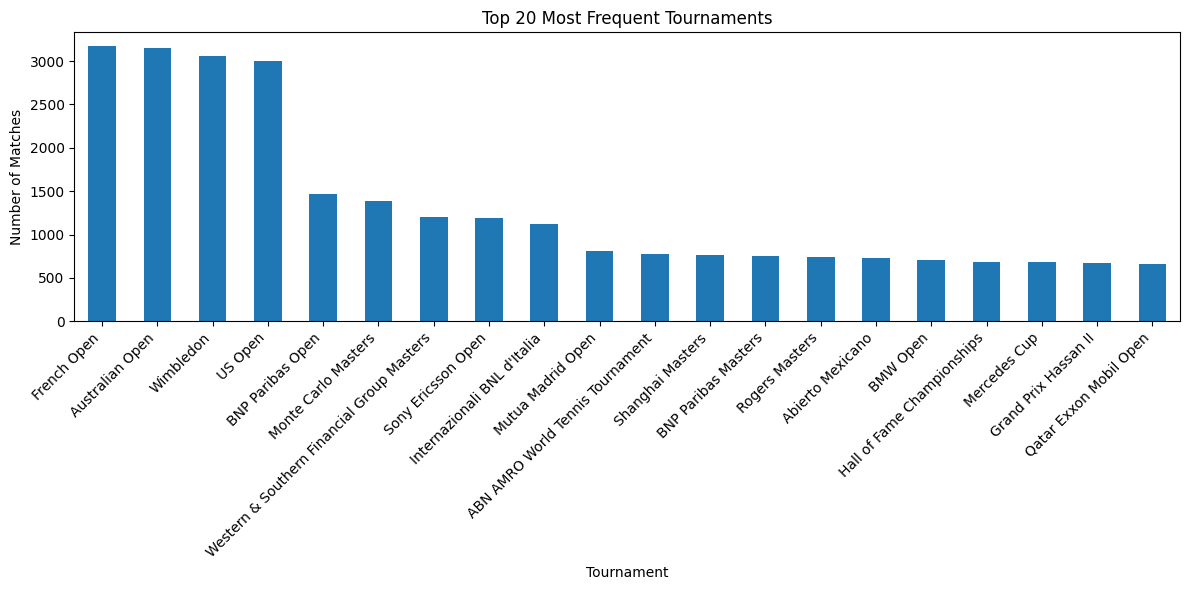

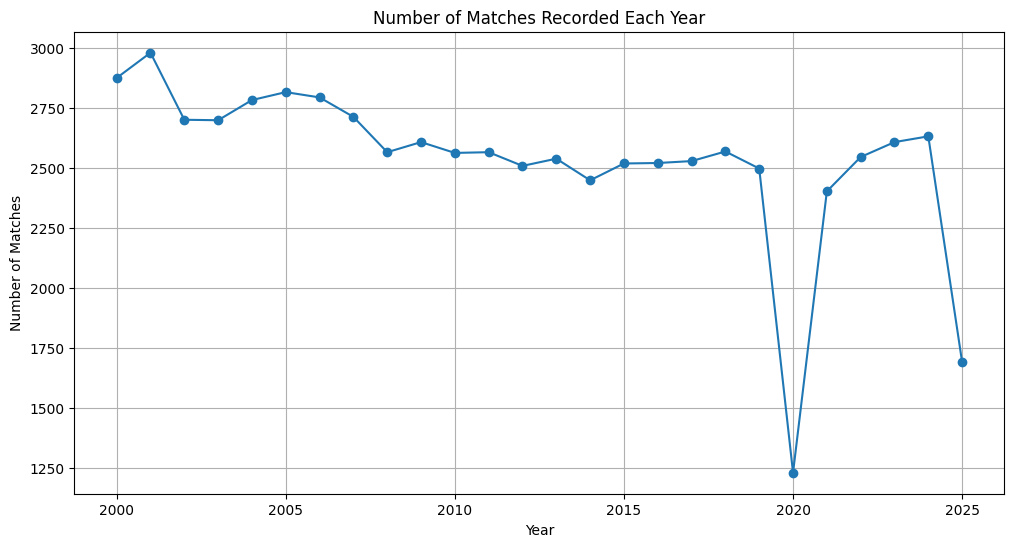

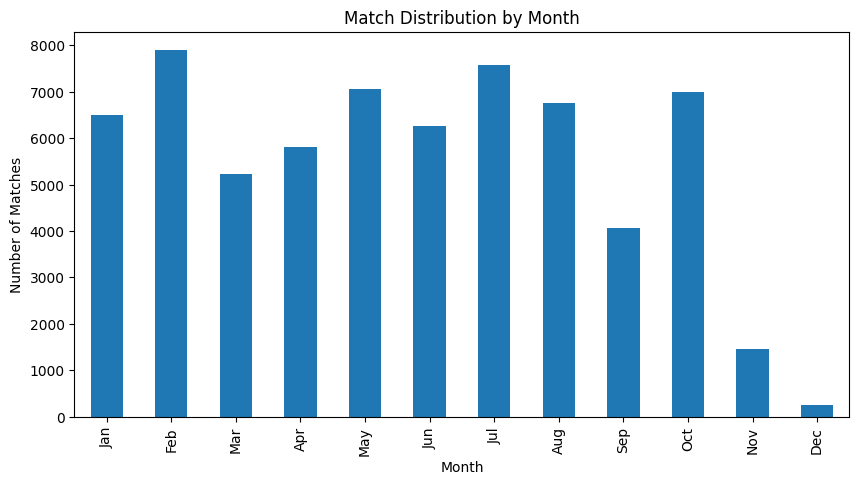

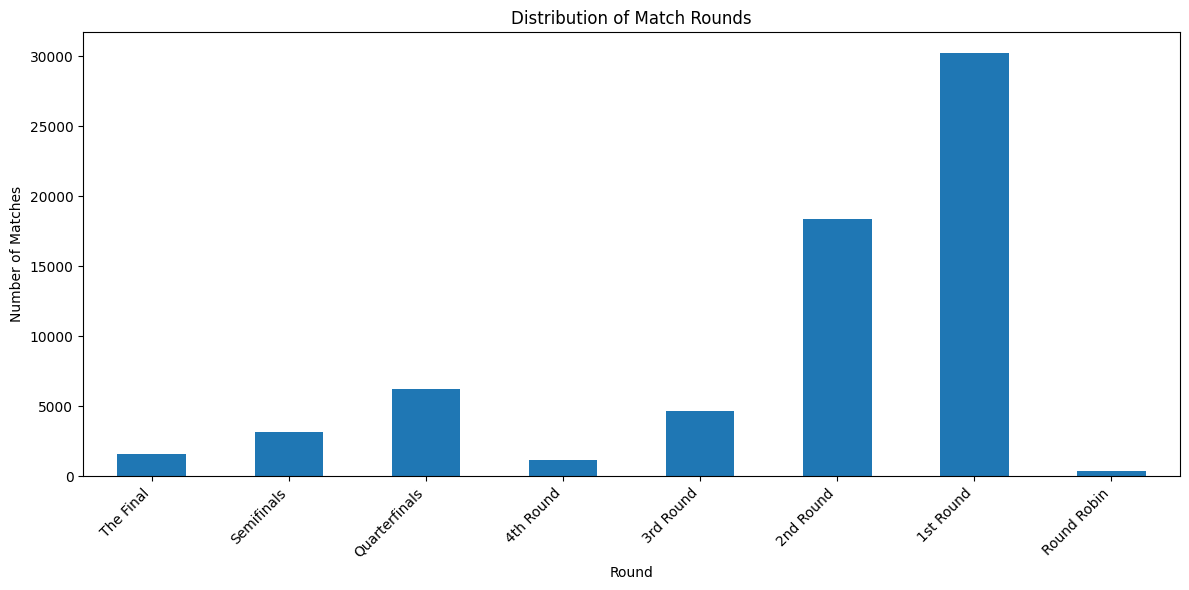

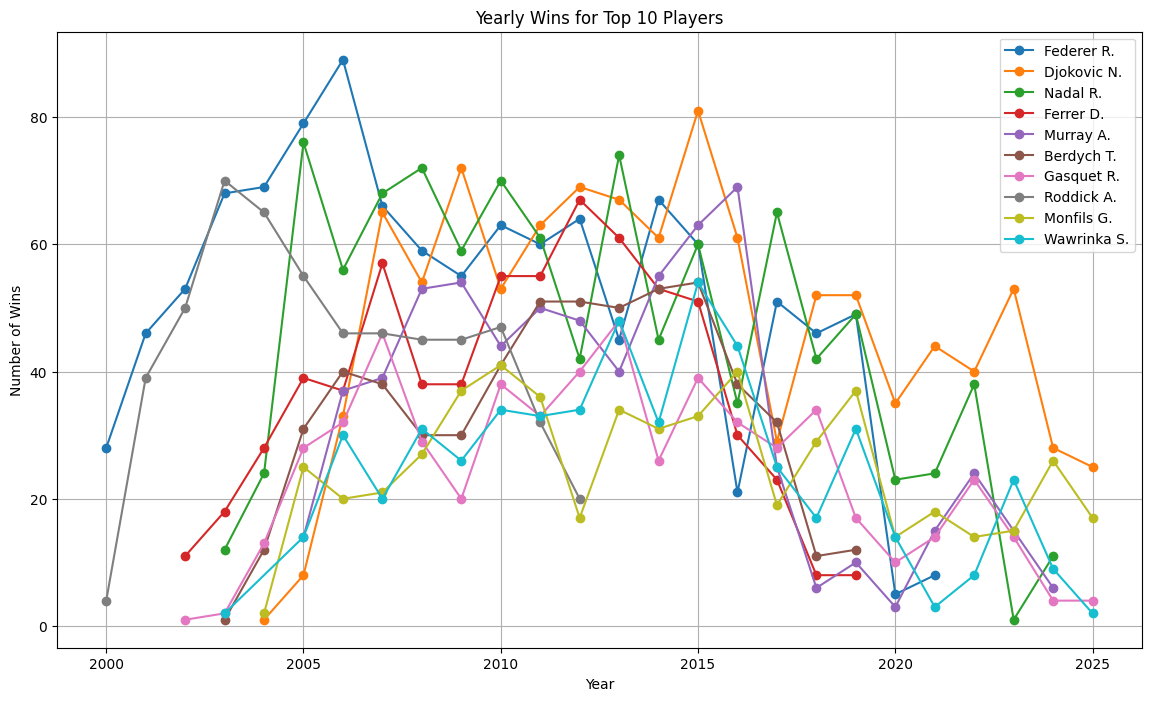

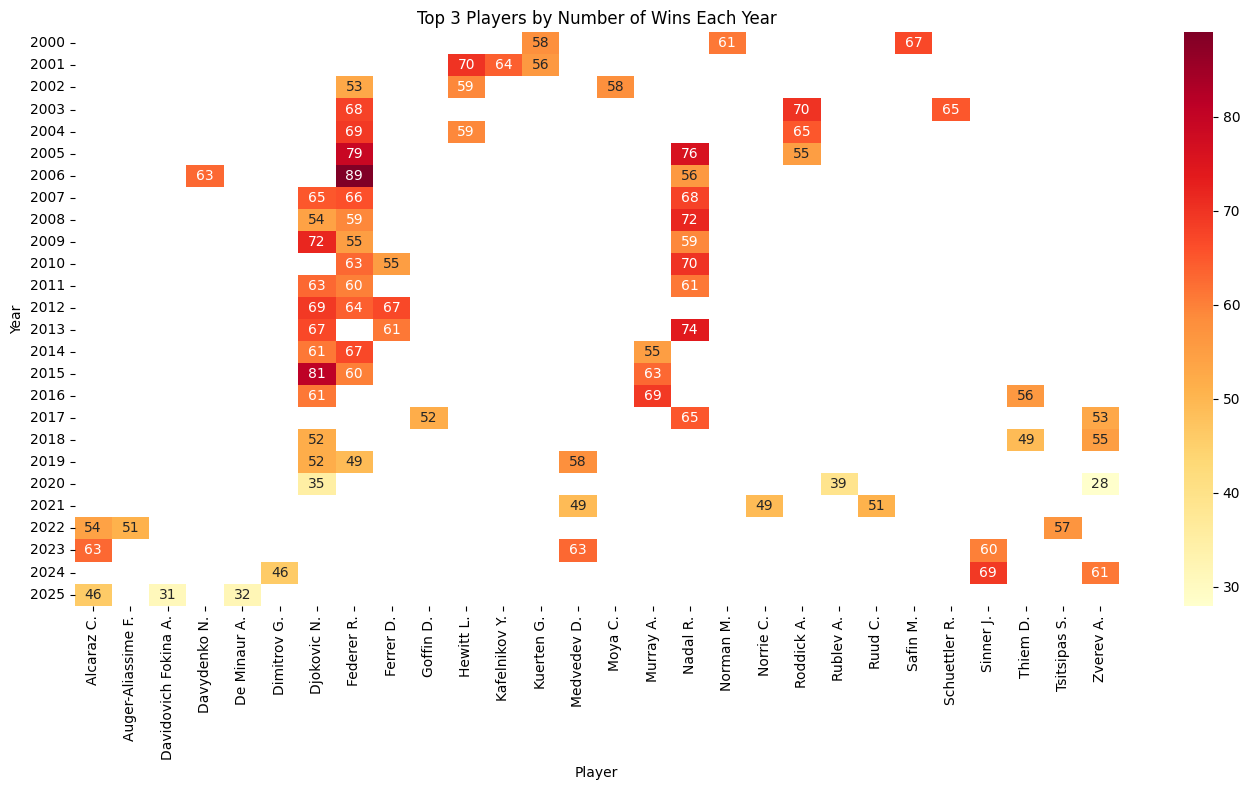

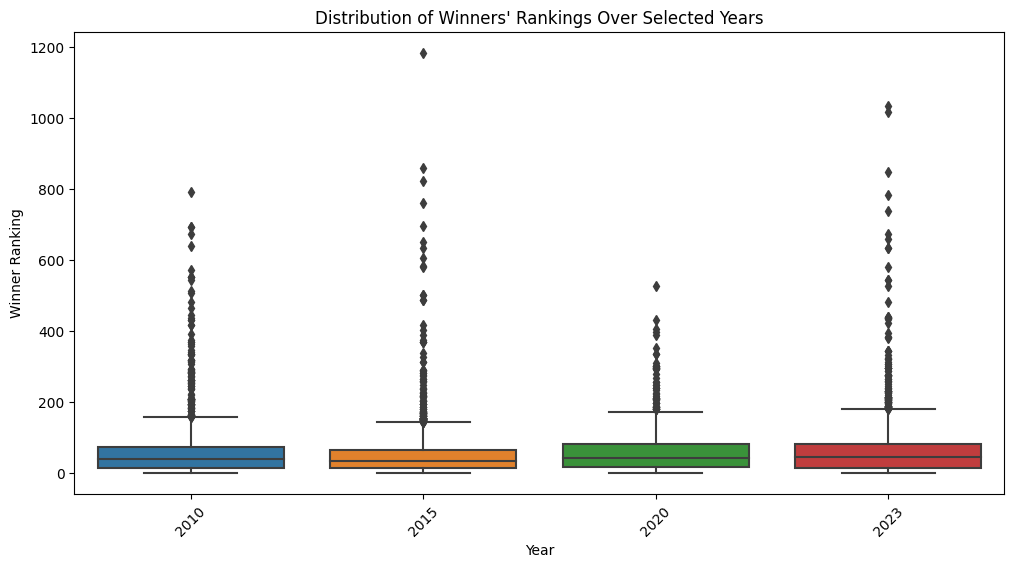


Favorite Win Rate: 64.65%


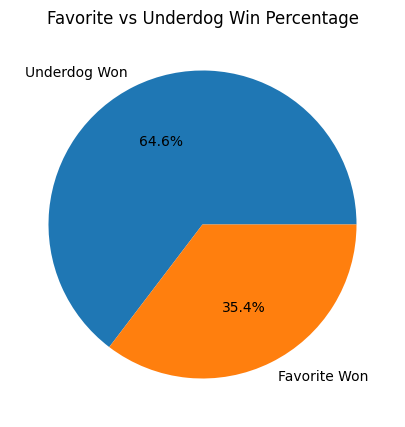

<Figure size 1200x600 with 0 Axes>

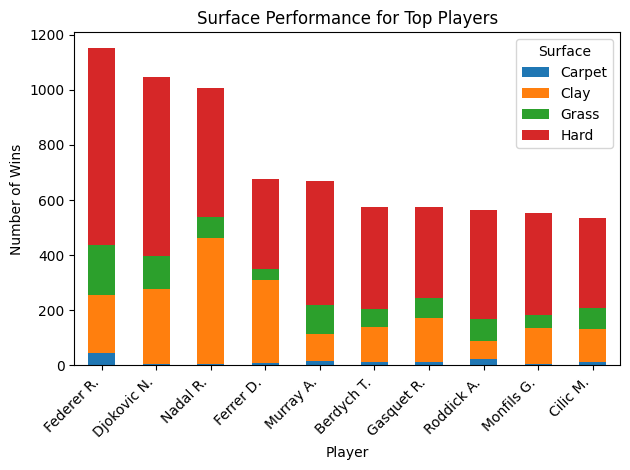

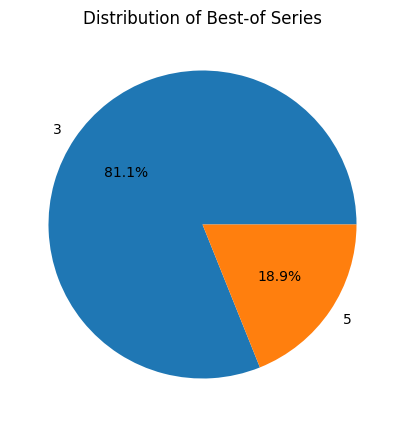

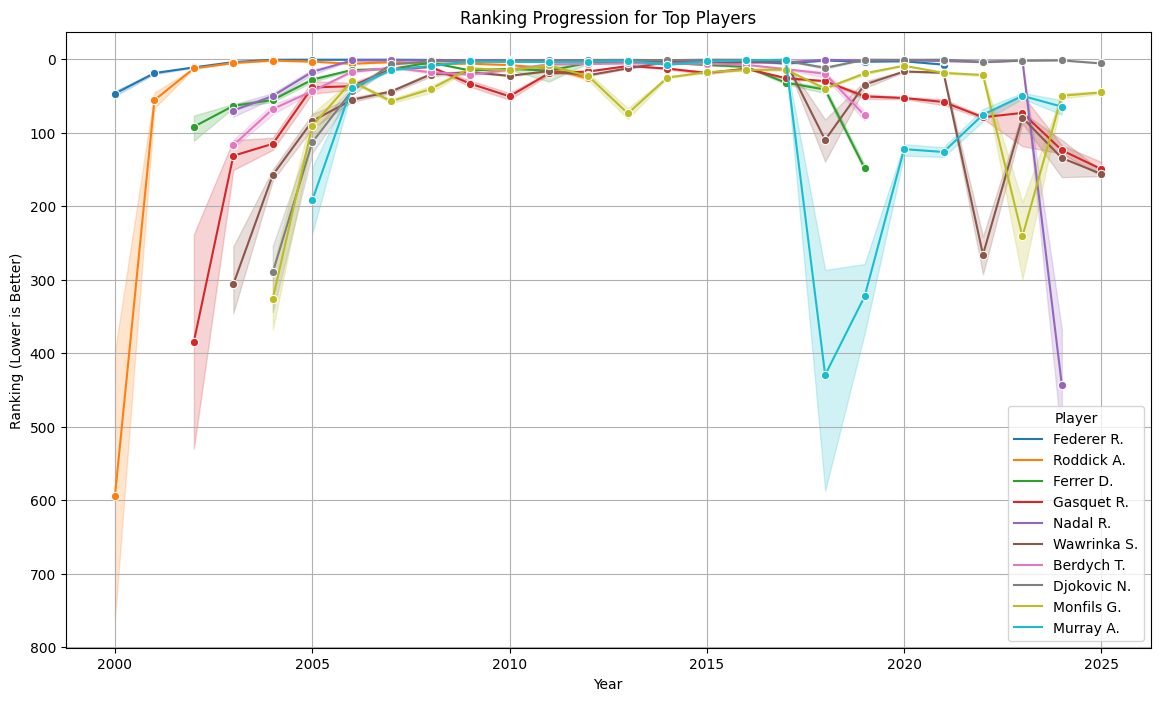

In [11]:
from datetime import datetime

# 1. Initial Data Exploration
print("Data Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# 2. Tournament Analysis
plt.figure(figsize=(12,6))
df['Tournament'].value_counts().head(20).plot(kind='bar')
plt.title('Top 20 Most Frequent Tournaments')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 3. Temporal Analysis
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Matches per Year
plt.figure(figsize=(12,6))
matches_per_year = df['Year'].value_counts().sort_index()
matches_per_year.plot(kind='line', marker='o')
plt.title('Number of Matches Recorded Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Matches')
plt.grid(True)
plt.show()

# Matches per Month (across all years)
plt.figure(figsize=(10,5))
df['Month'].value_counts().sort_index().plot(kind='bar')
plt.title('Match Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Number of Matches')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

# Corrected Round Analysis
plt.figure(figsize=(12,6))

# Use the actual round names from your data
round_counts = df['Round'].value_counts()

# Create a sensible order based on your actual data
round_order = [
    'The Final',
    'Semifinals',
    'Quarterfinals',
    '4th Round',
    '3rd Round',
    '2nd Round',
    '1st Round',
    'Round Robin'
]

# Reindex with actual rounds present in your data
round_counts = round_counts.reindex(round_order).dropna()

round_counts.plot(kind='bar')
plt.title('Distribution of Match Rounds')
plt.xlabel('Round')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Player Development Analysis

# Alternative method using DataFrame operations
winners = df[['Year', 'Winner', 'Rank_1', 'Rank_2']].copy()
winners['Player'] = winners['Winner']
winners['Rank'] = np.where(df['Winner'] == df['Player_1'], df['Rank_1'], df['Rank_2'])

losers = df[['Year', 'Player_1', 'Player_2', 'Rank_1', 'Rank_2']].copy()
losers['Player'] = np.where(df['Winner'] == df['Player_1'], df['Player_2'], df['Player_1'])
losers['Rank'] = np.where(df['Winner'] == df['Player_1'], df['Rank_2'], df['Rank_1'])
losers = losers[['Year', 'Player', 'Rank']]

# Combine for player performance analysis
all_matches = pd.concat([
    df[['Year', 'Player_1', 'Rank_1']].rename(columns={'Player_1': 'Player', 'Rank_1': 'Rank'}),
    df[['Year', 'Player_2', 'Rank_2']].rename(columns={'Player_2': 'Player', 'Rank_2': 'Rank'})
])

# Top 10 players by number of wins
top_players = df['Winner'].value_counts().head(10).index

plt.figure(figsize=(14,8))
for player in top_players:
    player_data = df[df['Winner'] == player].groupby('Year').size()
    plt.plot(player_data.index, player_data.values, label=player, marker='o')
plt.title('Yearly Wins for Top 10 Players')
plt.xlabel('Year')
plt.ylabel('Number of Wins')
plt.legend()
plt.grid(True)
plt.show()

# Most robust version
yearly_wins = df.groupby(['Year', 'Winner']).size().reset_index(name='Wins')

# Get top 3 for each year
yearly_top3 = yearly_wins.sort_values(['Year', 'Wins'], ascending=[True, False]) \
                         .groupby('Year') \
                         .head(3)

# Pivot for heatmap
yearly_top3_pivot = yearly_top3.pivot(index='Year', columns='Winner', values='Wins')

plt.figure(figsize=(14, 8))
sns.heatmap(yearly_top3_pivot, cmap='YlOrRd', annot=True, fmt='g')
plt.title('Top 3 Players by Number of Wins Each Year')
plt.xlabel('Player')
plt.ylabel('Year')
plt.tight_layout()
plt.show()
# Ranking Analysis
df['Winner_Rank'] = np.where(df['Winner'] == df['Player_1'], df['Rank_1'], df['Rank_2'])
df['Loser_Rank'] = np.where(df['Winner'] == df['Player_1'], df['Rank_2'], df['Rank_1'])

plt.figure(figsize=(12,6))
sns.boxplot(x='Year', y='Winner_Rank', data=df[df['Year'].isin([2010,2015,2020,2023])])
plt.title('Distribution of Winners\' Rankings Over Selected Years')
plt.xlabel('Year')
plt.ylabel('Winner Ranking')
plt.xticks(rotation=45)
plt.show()

#  Odds Analysis
df['Favorite_Won'] = ((df['Odd_1'] < df['Odd_2']) & (df['Winner'] == df['Player_1'])) | \
                     ((df['Odd_2'] < df['Odd_1']) & (df['Winner'] == df['Player_2']))

favorite_win_rate = df['Favorite_Won'].mean()
print(f"\nFavorite Win Rate: {favorite_win_rate:.2%}")

plt.figure(figsize=(10,5))
df['Favorite_Won'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Underdog Won', 'Favorite Won'])
plt.title('Favorite vs Underdog Win Percentage')
plt.ylabel('')
plt.show()

# Surface Performance Analysis
surface_performance = df.groupby(['Winner', 'Surface']).size().unstack().fillna(0)
surface_performance['Total'] = surface_performance.sum(axis=1)
top_players_surface = surface_performance.nlargest(10, 'Total')

plt.figure(figsize=(12,6))
top_players_surface.drop('Total', axis=1).plot(kind='bar', stacked=True)
plt.title('Surface Performance for Top Players')
plt.xlabel('Player')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Best of Series Analysis
plt.figure(figsize=(8,5))
df['Best of'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Best-of Series')
plt.ylabel('')
plt.show()

# Player Ranking Points Analysis
top_players_pts = all_matches[all_matches['Player'].isin(top_players)]

plt.figure(figsize=(14,8))
sns.lineplot(data=top_players_pts, x='Year', y='Rank', hue='Player', marker='o')
plt.gca().invert_yaxis()  # Lower rank = better
plt.title('Ranking Progression for Top Players')
plt.xlabel('Year')
plt.ylabel('Ranking (Lower is Better)')
plt.grid(True)
plt.show()

### We count the number of wins on each floor

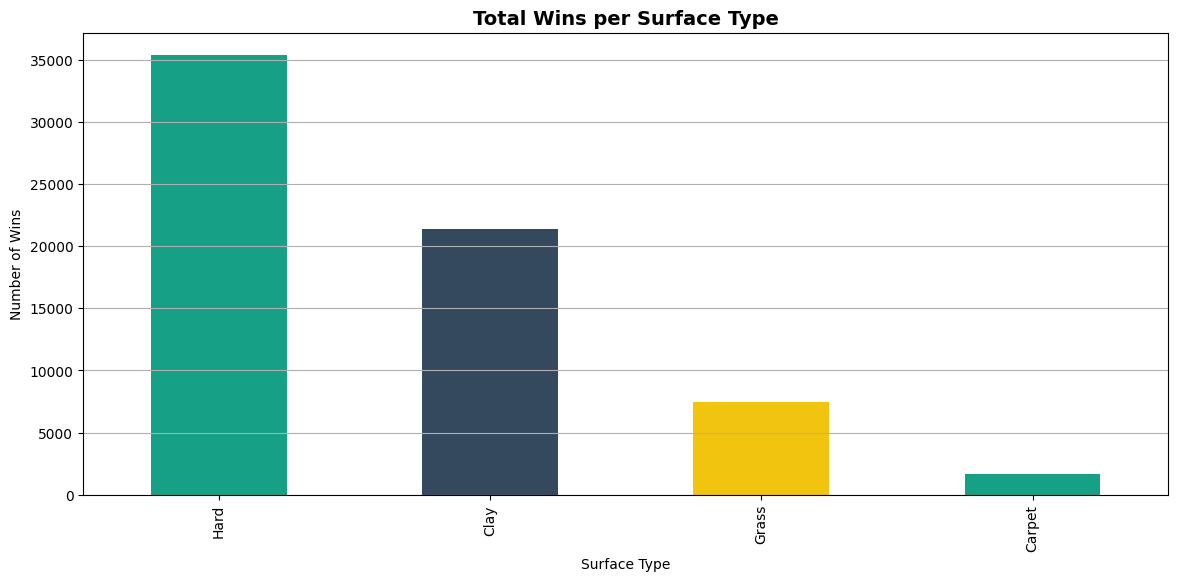

In [12]:
# Number of wins by floor
surface_wins = df.groupby('Surface')['Winner'].value_counts().unstack().fillna(0)

# Show top 5 players for each floor type
top_players_per_surface = surface_wins.apply(lambda x: x.sort_values(ascending=False).head(5))

plt.figure(figsize=(14, 6))
surface_wins.sum(axis=1).sort_values(ascending=False).plot(kind='bar', color=['#16a085', '#34495e', '#f1c40f'])
plt.title('Total Wins per Surface Type', fontsize=14, fontweight='bold')
plt.ylabel('Number of Wins')
plt.xlabel('Surface Type')
plt.grid(axis='y')
plt.show()


### 📊 Multidimensional Analysis - GroupBy
- We perform an analysis using GroupBy to show the relationship between more than one categorical column, such as:

- Number of matches by each surface type and venue (Court: Indoor/Outdoor)

- Distribution of the different rounds (Round) according to the type of tournament (Series)

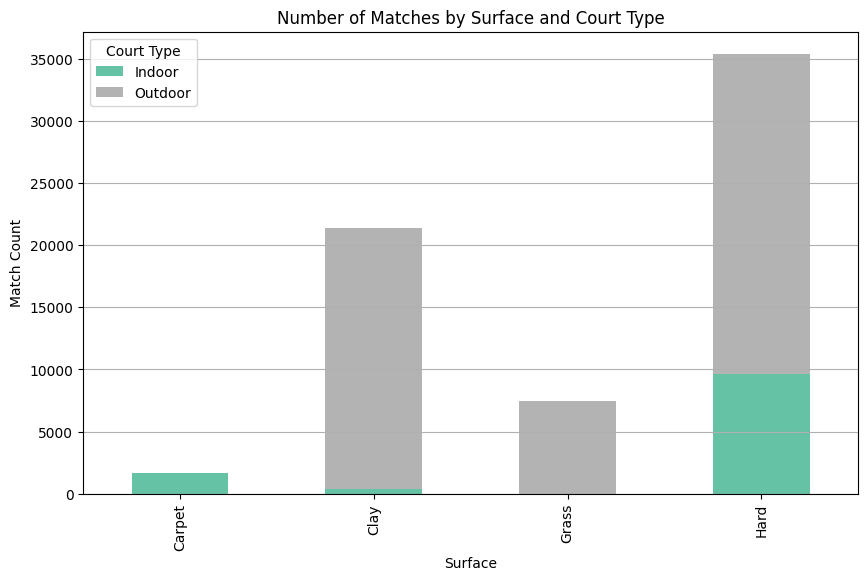

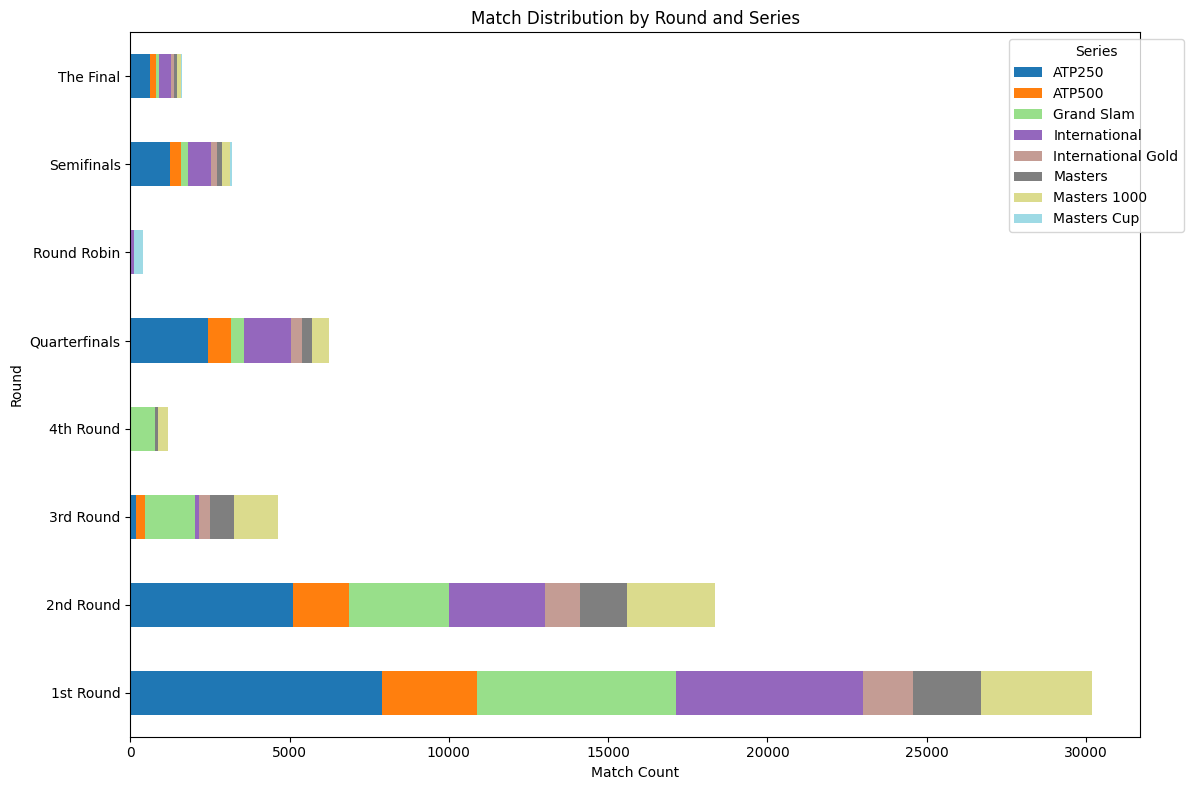

In [13]:
# Number of matches by Surface and Court
surface_court_counts = df.groupby(['Surface', 'Court']).size().unstack()

surface_court_counts.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
plt.title('Number of Matches by Surface and Court Type')
plt.ylabel('Match Count')
plt.xlabel('Surface')
plt.legend(title='Court Type')
plt.grid(axis='y')
plt.show()

# Number of matches by Round and Series
round_series_counts = df.groupby(['Round', 'Series']).size().unstack().fillna(0)

# show in graph
round_series_counts.plot(kind='barh', stacked=True, figsize=(12,8), colormap='tab20')
plt.title('Match Distribution by Round and Series')
plt.xlabel('Match Count')
plt.ylabel('Round')
plt.legend(title='Series', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


## **🏆 Winner Analysis: Who Really Wins?**

In [14]:
### 1️⃣ Rank Difference vs Winner
df['Rank_Diff'] = df['Rank_2'] - df['Rank_1']
### 2️⃣ Points Difference vs Winner
df['Pts_Diff'] = df['Pts_1'] - df['Pts_2']
### 3️⃣ Odds Difference vs Winner
df['Odds_Diff'] = df['Odd_2'] - df['Odd_1']


## **Data Modeling for feature**

In [15]:
df["Target"] = (df["Winner"] == df["Player_1"]).astype(int)

#delete missing value in data of model
df_model = df[["Rank_Diff", "Pts_Diff", "Odds_Diff", "Target"]].dropna()
from sklearn.model_selection import train_test_split

X = df_model[["Rank_Diff", "Pts_Diff", "Odds_Diff"]]
y = df_model["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## **Try Classifiers**

In [16]:
#Let’s try three classifiers: Logistic Regression, Random Forest, and Gradient Boosting.

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

# predict
preds = gb.predict(X_test)
probs = gb.predict_proba(X_test)[:,1] 

# evalute
print("🎯 Accuracy:", accuracy_score(y_test, preds))
print("🔍 Classification Report:\n", classification_report(y_test, preds))
print("🔥 ROC AUC Score:", roc_auc_score(y_test, probs))



🎯 Accuracy: 0.6927980572209153
🔍 Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.68      0.69      6557
           1       0.69      0.71      0.70      6620

    accuracy                           0.69     13177
   macro avg       0.69      0.69      0.69     13177
weighted avg       0.69      0.69      0.69     13177

🔥 ROC AUC Score: 0.7650326304260984


## **Feature Importance**

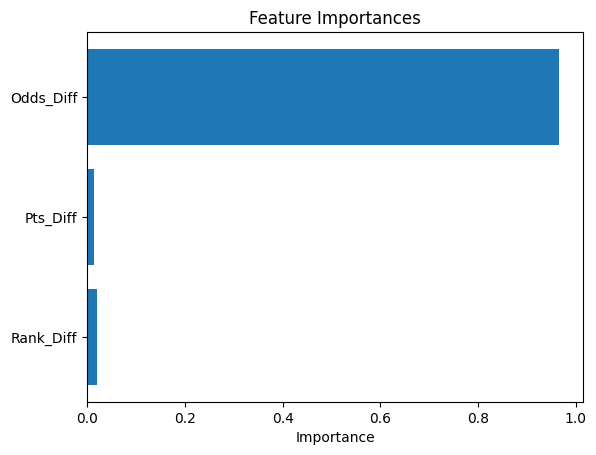

In [17]:

importance = gb.feature_importances_
features = ["Rank_Diff", "Pts_Diff", "Odds_Diff"]

plt.barh(features, importance)
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.show()


In [18]:
X_no_odds = df_model[["Rank_Diff", "Pts_Diff"]]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_no_odds, y, test_size=0.2, random_state=42)

gb2 = GradientBoostingClassifier(random_state=42)
gb2.fit(X_train2, y_train2)

preds2 = gb2.predict(X_test2)
print("Accuracy without Odds_Diff:", accuracy_score(y_test2, preds2))


Accuracy without Odds_Diff: 0.6515140016695757


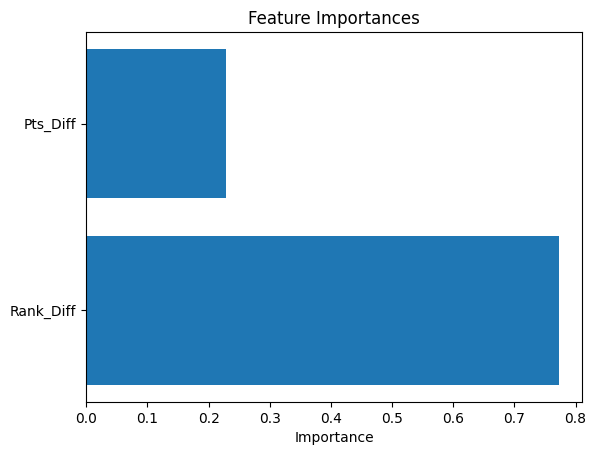

In [19]:

importance = gb2.feature_importances_
features = ["Rank_Diff", "Pts_Diff"]

plt.barh(features, importance)
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.show()


## **Conclution**

### ✅ Interpretation:
- Odds_Diff is the difference between the Betting Odds between Player 1 and Player 2, and essentially reflects the market's expectation of the winner — which has high predictive power.

- Rank_Diff and Pts_Diff are clearly much less important, possibly because:

- The Odds are originally based on factors such as rating, points, and player performance, so the model finds that the Odds_Diff is sufficient on its own.

- Ranks are not always accurate in expressing the player's actual strength at the time of the match.